# Image Segmentation - Skin Cancer (HAM10000)

In this notebook, we apply segmentation techniques to extract the lesion (region of interest) from skin images.

### Objectives:
- Use preprocessed images
- Apply segmentation techniques:
  - Thresholding (Binary + Otsu)
  - K-means clustering
- Extract ROI (lesion area)
- Compare segmentation results

Segmentation is crucial for focusing on the affected skin region.

In [ ]:
def setup_kaggle():
    from google.colab import files
    files.upload()  # upload kaggle.json

    !pip install -q kaggle

    import os
    os.makedirs('/root/.kaggle', exist_ok=True)
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json

In [ ]:
setup_kaggle()

Saving kaggle.json to kaggle.json


In [ ]:
def download_dataset():
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
    !unzip -q skin-cancer-mnist-ham10000.zip
    print("Dataset downloaded and extracted ")

In [ ]:
download_dataset()

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:35<00:00, 155MB/s]

Dataset downloaded and extracted 


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os
import random

def load_image_paths(base_path="/content"):
    paths = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".jpg"):
                paths.append(os.path.join(root, file))
    return paths

# Load paths
image_paths = load_image_paths()

# Take samples
sample_paths = random.sample(image_paths, 10)

print("Samples loaded:", len(sample_paths))

Samples loaded: 10


In [ ]:
def load_and_preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gaussian = cv2.GaussianBlur(gray, (5,5), 0)

    return img, gray, gaussian

In [ ]:
img, gray, gaussian = load_and_preprocess(sample_paths[0])

## Thresholding Segmentation

We convert the image into a binary image to separate lesion from background.

Types:
- Binary Threshold
- Otsu Threshold (automatic)

In [ ]:
def threshold_segmentation(gray):
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, otsu = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    otsu = cv2.bitwise_not(otsu)

    return binary, otsu

In [ ]:
def show_threshold_results(img, gray):
    binary, otsu = threshold_segmentation(gray)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(binary, cmap='gray')
    plt.title("Binary")

    plt.subplot(1,3,3)
    plt.imshow(otsu, cmap='gray')
    plt.title("Otsu (Lesion White)")

    plt.show()

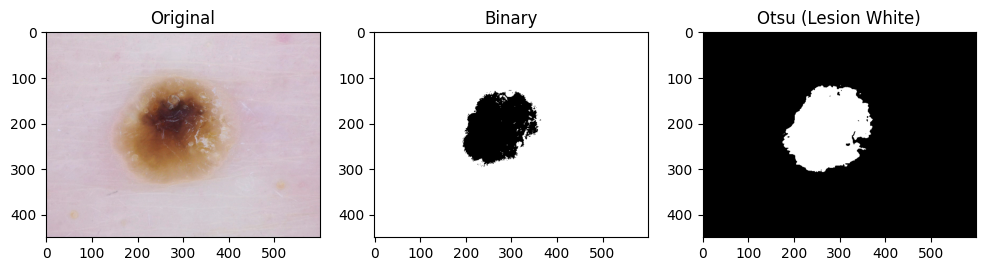

In [ ]:
show_threshold_results(img, gray)

## ROI Extraction

We extract the lesion area using mask.

In [ ]:
def extract_roi(img, mask):
    roi = cv2.bitwise_and(img, img, mask=mask)
    return roi

In [ ]:
def show_roi(path):
    img, gray, _ = load_and_preprocess(path)

    _, otsu = threshold_segmentation(gray)
    roi = extract_roi(img, otsu)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(otsu, cmap='gray')
    plt.title("Mask (White Lesion)")

    plt.subplot(1,2,2)
    plt.imshow(roi)
    plt.title("ROI")

    plt.show()

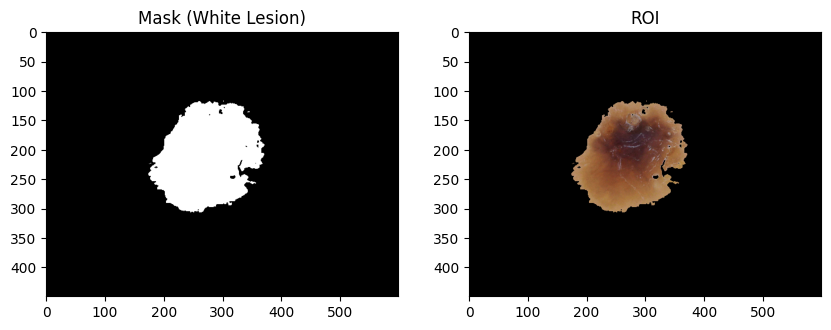

In [ ]:
show_roi(sample_paths[0])

## K-Means Segmentation

We cluster pixels based on color to separate regions.

K = number of segments

In [ ]:
def kmeans_segmentation(img, k=3):
    pixels = img.reshape((-1, 3))
    pixels = np.float32(pixels)

    criteria = (cv2.TERM_CRITERIA_EPS +
                cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

    _, labels, centers = cv2.kmeans(
        pixels, k, None, criteria, 10,
        cv2.KMEANS_RANDOM_CENTERS
    )

    labels = labels.reshape(img.shape[:2])

    return labels

## Convert K-Means Output to Binary Mask

In [ ]:
def kmeans_to_mask(img, labels):
    import numpy as np
    import cv2

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    cluster_values = []
    for i in range(np.max(labels)+1):
        cluster_values.append(np.mean(gray[labels == i]))

    lesion_cluster = np.argmin(cluster_values)

    mask = (labels == lesion_cluster).astype(np.uint8) * 255

    return mask

In [ ]:
def show_kmeans_mask(path, k=3):
    img, _, _ = load_and_preprocess(path)

    labels = kmeans_segmentation(img, k)
    mask = kmeans_to_mask(img, labels)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("K-Means Mask (White Lesion)")

    plt.show()

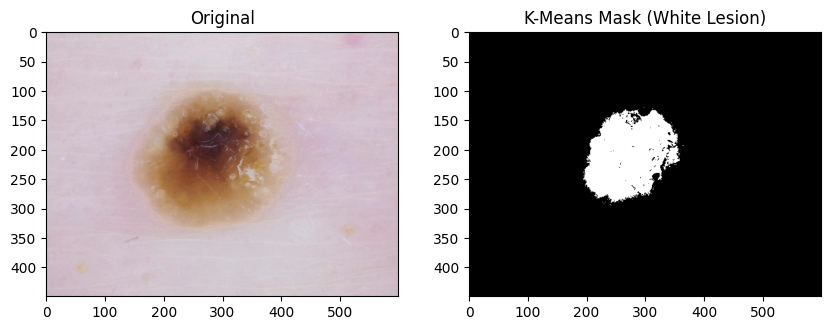

In [ ]:
show_kmeans_mask(sample_paths[0], k=3)

## Extract ROI using K-Means

In [ ]:
def show_kmeans_roi(path, k=3):
    img, _, _ = load_and_preprocess(path)

    labels = kmeans_segmentation(img, k)
    mask = kmeans_to_mask(img, labels)

    roi = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask (White Lesion)")

    plt.subplot(1,3,3)
    plt.imshow(roi)
    plt.title("ROI")

    plt.show()

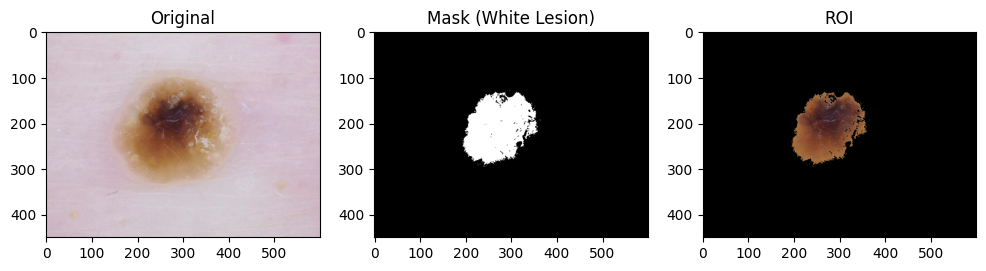

In [ ]:
show_kmeans_roi(sample_paths[0], k=3)

## Batch Processing (Threshold vs K-Means vs Combined)

We compare:
- Otsu Thresholding
- K-Means Segmentation
- Combined Result (Otsu + K-Means)

In [ ]:
def segmentation_batch(sample_paths):

    for path in sample_paths[:5]:

        img, gray, _ = load_and_preprocess(path)

        # Otsu
        _, otsu = threshold_segmentation(gray)

        # K-means
        labels = kmeans_segmentation(img, 3)
        kmeans_mask = kmeans_to_mask(img, labels)

        # Combined
        combined_mask = cv2.bitwise_or(otsu, kmeans_mask)

        # ROI
        roi_otsu = cv2.bitwise_and(img, img, mask=otsu)
        roi_kmeans = cv2.bitwise_and(img, img, mask=kmeans_mask)
        roi_combined = cv2.bitwise_and(img, img, mask=combined_mask)

        # Show
        plt.figure(figsize=(15,4))

        plt.subplot(2,4,1)
        plt.imshow(img)
        plt.title("Original")

        plt.subplot(2,4,2)
        plt.imshow(otsu, cmap='gray')
        plt.title("Otsu")

        plt.subplot(2,4,3)
        plt.imshow(kmeans_mask, cmap='gray')
        plt.title("KMeans")

        plt.subplot(2,4,4)
        plt.imshow(combined_mask, cmap='gray')
        plt.title("Combined")

        plt.subplot(2,4,6)
        plt.imshow(roi_otsu)
        plt.title("ROI Otsu")

        plt.subplot(2,4,7)
        plt.imshow(roi_kmeans)
        plt.title("ROI KMeans")

        plt.subplot(2,4,8)
        plt.imshow(roi_combined)
        plt.title("ROI Combined")

        plt.tight_layout()
        plt.show()

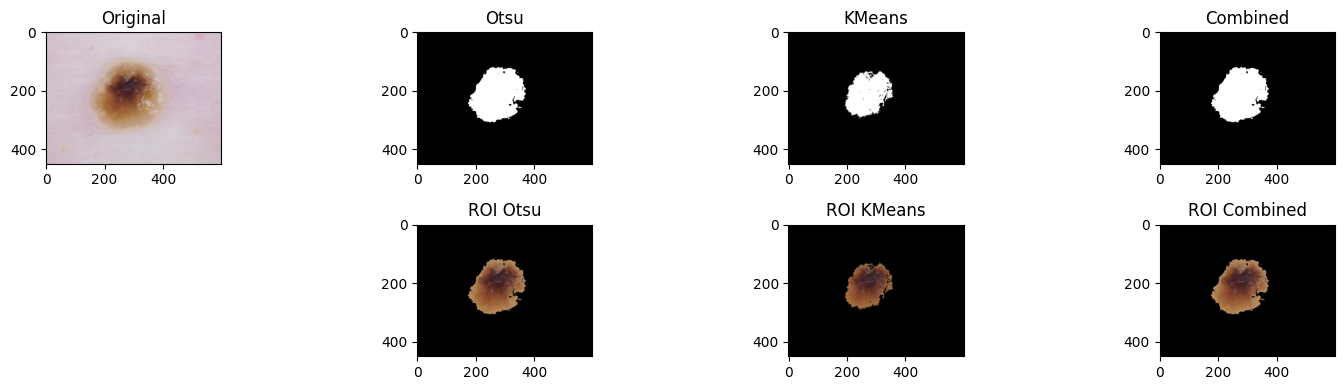

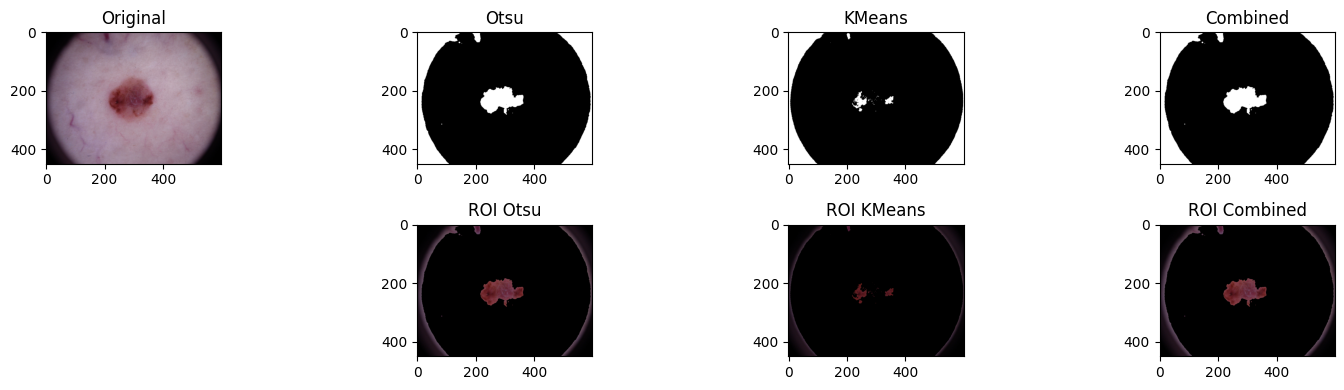

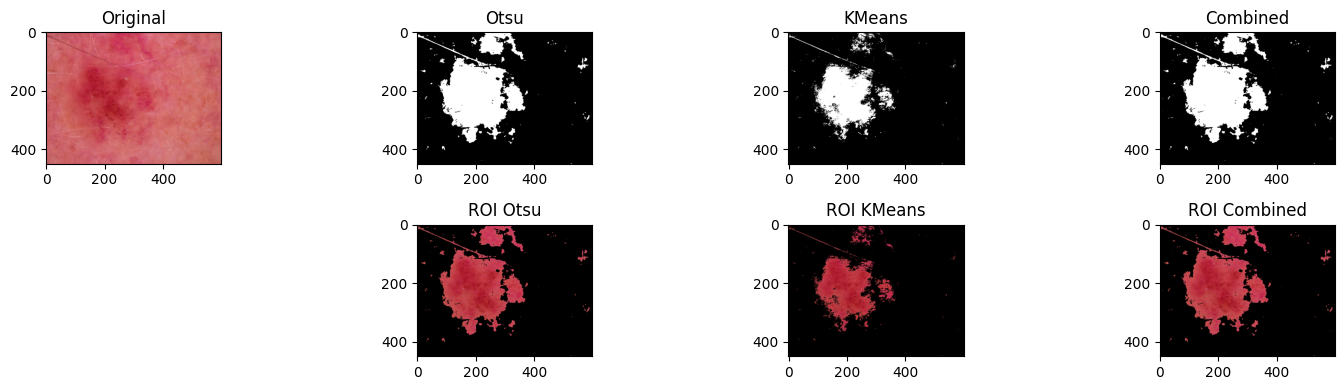

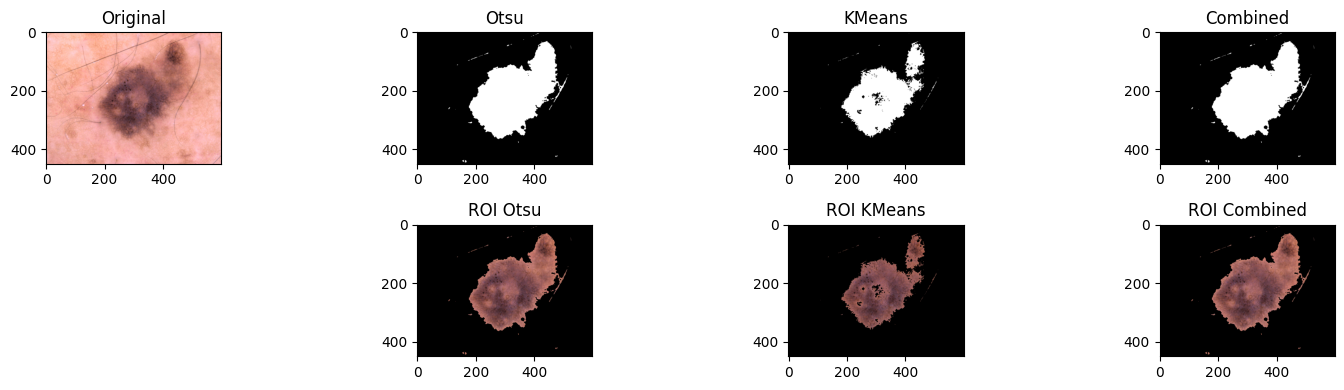

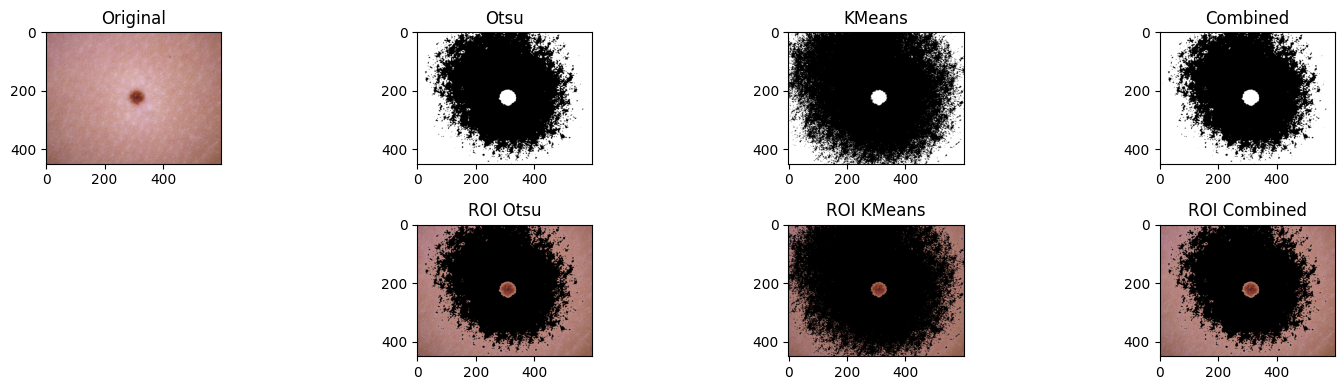

In [ ]:
segmentation_batch(sample_paths)

In [ ]:
import os
import cv2

def save_results(image_paths, save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(f"{save_dir}/roi", exist_ok=True)
    os.makedirs(f"{save_dir}/mask", exist_ok=True)

    for i, path in enumerate(image_paths):

        img, gray, _ = load_and_preprocess(path)

        # Otsu
        _, otsu = threshold_segmentation(gray)

        # K-means
        labels = kmeans_segmentation(img, 3)
        kmeans_mask = kmeans_to_mask(img, labels)

        # Combined
        combined_mask = cv2.bitwise_or(otsu, kmeans_mask)

        # ROI
        roi = cv2.bitwise_and(img, img, mask=combined_mask)

        # Save
        cv2.imwrite(f"{save_dir}/mask/mask_{i}.png", combined_mask)
        cv2.imwrite(f"{save_dir}/roi/roi_{i}.jpg",
                    cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))

    print("Saved successfully")

In [37]:
save_results(image_paths)

Saved successfully


In [38]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
!cp -r results /content/drive/MyDrive/